In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import visualkeras

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

print(train_images.shape)

(50000, 32, 32, 3)


In [3]:
train_images, test_images = train_images / 255.0, test_images / 255.0

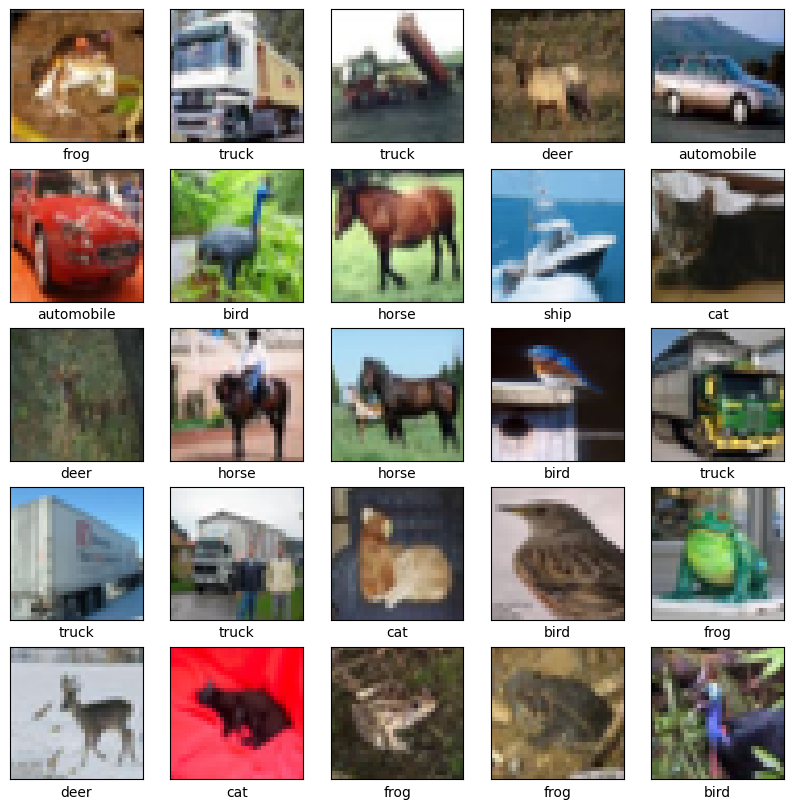

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])

plt.show()

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv1'),
    tf.keras.layers.MaxPooling2D((2, 2), name='max_pool1'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
    tf.keras.layers.MaxPooling2D((2, 2), name='max_pool2'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', name='dense1'),
    tf.keras.layers.Dense(10, activation='softmax', name='output')
])

2024-07-25 11:13:34.552637: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-07-25 11:13:34.553677: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2024-07-25 11:13:34.553697: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2024-07-25 11:13:34.554373: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-07-25 11:13:34.555176: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1 (MaxPooling2D)        │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool2 (MaxPooling2D)        │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

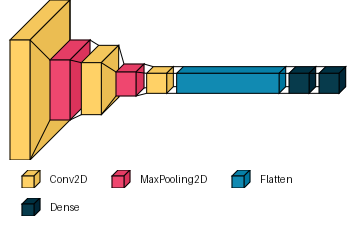

In [23]:
visualkeras.layered_view(model, legend=True)

In [7]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10


2024-07-25 11:13:38.505662: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.3508 - loss: 1.7477 - val_accuracy: 0.4964 - val_loss: 1.4042
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5661 - loss: 1.2268 - val_accuracy: 0.6023 - val_loss: 1.1482
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6245 - loss: 1.0642 - val_accuracy: 0.6238 - val_loss: 1.0720
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6614 - loss: 0.9607 - val_accuracy: 0.6678 - val_loss: 0.9637
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.6930 - loss: 0.8810 - val_accuracy: 0.6685 - val_loss: 0.9487
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7074 - loss: 0.8330 - val_accuracy: 0.6940 - val_loss: 0.8931
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.7296 - loss: 0.7777 - val_accuracy: 0.6777 - val_loss: 0.9416
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7387 - loss: 0.74

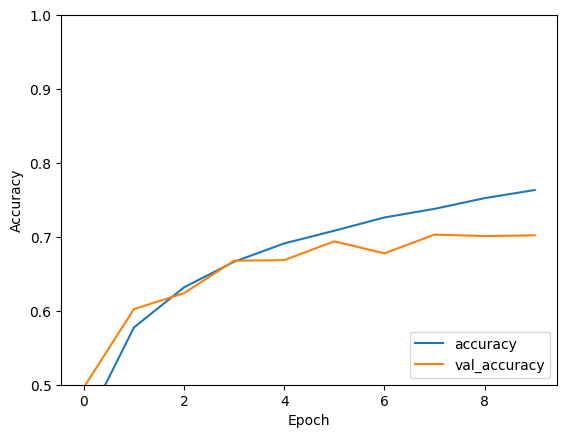

In [9]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

In [10]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)
print('\nTest loss:', test_loss)

313/313 - 1s - 4ms/step - accuracy: 0.7021 - loss: 0.8880

Test accuracy: 0.7020999789237976

Test loss: 0.8879837989807129


# Visualizing the Convolutional Layers

In [11]:
sample_img = test_images[:1]
print(sample_img.shape)

conv_layers = [layer for layer in model.layers if 'conv' in layer.name]

outputs = []

for conv_layer in conv_layers:
    filter_model = tf.keras.models.Model(model.inputs, conv_layer.output)
    output = filter_model.predict(sample_img)
    
    outputs.append(output)

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


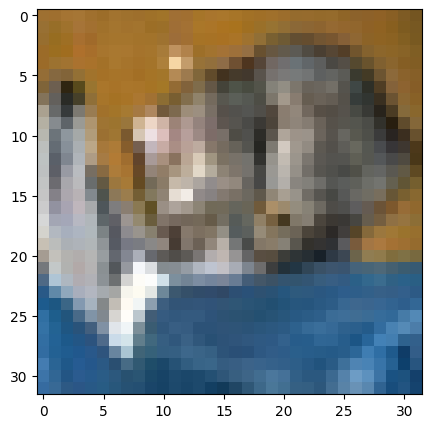

In [12]:
plt.figure(figsize=(5, 5))
plt.imshow(sample_img[0])
    
plt.show()

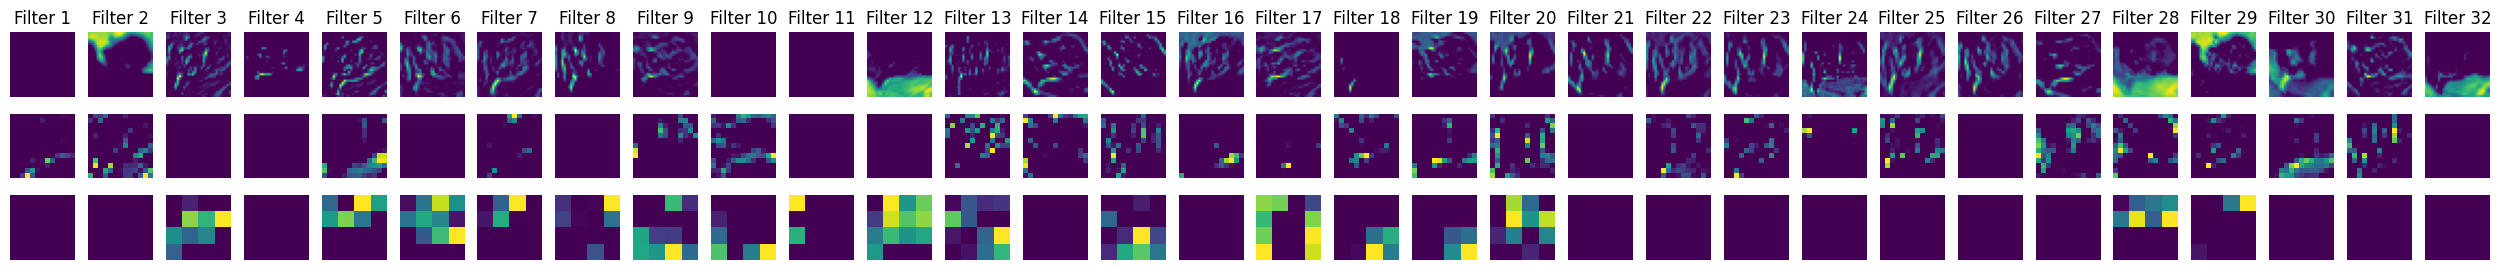

In [13]:
fig, axs = plt.subplots(3, 32, figsize=(32, 3))

for i, output in enumerate(outputs):
    for j in range(32):
        if i == 0:
            axs[i, j].set_title(f'Filter {j + 1}')
        
        axs[i, j].imshow(output[0, :, :, j])
        axs[i, j].axis('off')

plt.show()

In [18]:
flatten_model = tf.keras.models.Model(model.inputs, model.get_layer('flatten').output)
flatten_output = flatten_model.predict(sample_img)

for i in flatten_output[0]:
    print(i, end=' ')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
0.0 0.0 0.0 0.0 0.3168766 0.040186163 0.0 0.16458976 0.0 0.0 0.1272492 0.0 0.029740721 0.0 0.0 0.0 0.71711415 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.01921776 0.0 0.0 0.0 0.0 0.0 0.4398336 0.0 0.0 0.0 1.222508 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.12034386 0.0 0.14124471 0.9825368 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.09050706 0.0 0.0 0.39824614 0.22907376 0.0 0.0 0.0 0.0 1.5746294 0.35107172 0.0 0.0 0.0 0.68749726 0.0 0.0 0.99788284 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.40609998 0.0 0.0 0.0 0.0 0.0 0.1403417 0.0 0.0 0.0 0.28519735 0.0 0.0 0.0 0.0 0.0 0.0 0.4829066 0.0 0.0 0.0 1.0705054 0.38999736 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.9496969 0.93617314 0.7351512 0.01521308 0.45049247 0.0 0.0 0.83624697 0.16755657 0.0 0.08449504 0.0 0.0 0.0 0.0 0.3927407 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.545333 0.69954455 0.0 0.0 0.0 0.0 0.29019696 0.0 0.0 0.0 1.4528393 0.0 0.0 0.0 0.0 0.41229272 0.0 0.22835845 0.0

In [14]:
print('Predicted:', class_names[model.predict(sample_img).argmax()])
print('Actual:', class_names[test_labels[0][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted: cat
Actual: cat
